In [17]:
from utils import *

In [46]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 14,
    "figure.titlesize": 30,
})

In [19]:
import pandas as pd
import pickle
path_neuron_df = '/Users/cgty/Library/Mobile Documents/com~apple~CloudDocs/CLASSES/FSU/MyResearch/GITHUB/Spike-Train-Data-Analysis/Data/Temperature Data/NeuronDF.pickle' # fill this in yourself
pairs = pd.read_csv('pairs.csv',dtype= {'Date':str}) # pairs is a csv file that helps keep a fixed order for Mouse-Date pairs
with open(path_neuron_df,'rb') as file:
    Df = pickle.load(file)

In [20]:

# helper functions to work with Df
def get_raster(Mouse,Date,Taste,Trial,time_interval = [0,4000]):
    """
    INPUT:
    1) Mouse = str
    2) Date = str
    3) Taste = int
    4) Trial = int
    5) time_interval = list with two entries. It will tell the min and max time to look at in the raster. Set to 0ms - 4000ms by default.
    OUTPUT: numpy array. Will extract from Df the specified raster plot
    """
    frame = Df[(Df['MouseID'] == Mouse) & (Df['Date'] == Date) & (Df['Taste'] == Taste) & (Df['Trial'] == Trial)].iloc[:,7:] # Column 7 and on is spike train
    frame_array = np.array(frame) # turn it into a numpy array. This represents the whole 4000ms
    
    #### Extract the time interval specified ####
    time_begin = time_interval[0]
    time_end = time_interval[1]
    
    frame_array = frame_array[:,time_begin:time_end] # update the frame_array to extract the specified time interval

    return frame_array

def get_dates(Mouse):
    """
    INPUT:
    Mouse = str
    OUTPUT: numpy array consisting of dates the given mouse had trials
    """
     # get dates
    out = Df[(Df['MouseID'] == Mouse) & (Df['Taste'] == 0)]['Date'].unique() # This is taste independent. So, we will pick taste 0 as a representative.
    return out

def get_trial(Mouse, Date, Taste):
    """
    INPUT: 
    Mouse
    Date
    Taste
    OUTPUT:
    Number of trials
    """
    out = Df[(Df['MouseID'] == Mouse) & (Df['Date'] == Date) &(Df['Taste'] == Taste)]['Trial'].unique()
    return(len(out))  


def get_neurons(Mouse, Date):
    """
    Input
    Mouse: str
    Date: str 
    Returns
    Neurons that belong to the Mouse-Date pair 
    """
    row_mask = (Df["MouseID"] == Mouse) & (Df["Date"] == Date)
    neurons = np.unique(np.array(Df[row_mask]["Neuron"]))
    return neurons

def get_trial_from_neuron(neuron,taste,time_interval = [2000,4000]):
    """
    Input
    neuron: int -- neuron id index in Df
    taste: int -- 0, 1 or 2.
    time_interval = [2000,4000] by default
    Returns:
    array -- Returns all trials from the neuron-taste pair. array has shape (# of trials, end_time - begin_time)
    """
    row_mask = (Df["Neuron"] == neuron) & (Df["Taste"] == taste)
    trials = np.array(Df[row_mask].iloc[:,7:])
    begin_time = time_interval[0]
    end_time = time_interval[1]
    array = np.array(trials)[:,begin_time:end_time]

    return array

In [21]:
# Map Mouse-Date-Taste (MDT) to all of its corresponding rasters/trials
MDT_to_trials = {}             
for _, row in pairs.iterrows():
    Mouse = row["Mouse"]
    Date = row["Date"]

    for Taste in (0, 1, 2):
        # Assuming get_trial returns an integer count of trials
        n_trials = get_trial(Mouse=Mouse, Date=Date, Taste=Taste)

        raster_list = []
      

        for j in range(n_trials):
            # Fetch raster: Shape is likely (N_neurons, N_timepoints)
            raster = get_raster(Mouse=Mouse, Date=Date, Taste=Taste, Trial=j, time_interval=[2000, 4000])
            raster_list.append(raster)

        # Store
        MDT_to_trials[(Mouse, Date, Taste)] = raster_list

# TDA Pipeline with Repeated holdout validation

## 3-Class TDA

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

def rasters_to_barcode(list_of_rasters, dim = 0):
    list_of_barcodes = []
    for raster in list_of_rasters:
        vp_dm = VP_trivial(raster)
        dgm = ripser(vp_dm,distance_matrix= True)['dgms'][dim]
        list_of_barcodes.append(dgm)

    return list_of_barcodes

def tda_rhv(rasters,labels,dim = 0,n_repeats = 20, test_size = 0.3, random_state = 42): # TDA pipeline with repeated holdout validation (rhv)

    X_barcodes = rasters_to_barcode(X_rasters,dim = dim)
    n = len(X_barcodes)
    BDM = np.zeros((n, n), dtype=float)
    for i in range(n):
        for j in range(i + 1, n):
            if dim == 0:
                d = bottleneck_zero(X_barcodes[i], X_barcodes[j]) 
            else:
                d = persim.bottleneck(X_barcodes[i],X_barcodes[j])
            
            BDM[i, j] = d
            BDM[j, i] = d

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
        D_train = BDM[np.ix_(train_idx, train_idx)]
        D_test = BDM[np.ix_(test_idx, train_idx)]

        knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")
        knn.fit(D_train, y[train_idx])
        preds = knn.predict(D_test)

        scores.append(accuracy_score(y[test_idx], preds))

    mean_score = np.mean(scores) 
    return mean_score


In [23]:
# run a for loop to iterate through all Mouse-Date pairs
# as you do so, save the information in a pandas data frame
# first we do 3-class classification
results_list_3class = []
for index, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row['Mouse']
    Date = row['Date']

    stim_0_trials = MDT_to_trials[(Mouse, Date, 0)]
    stim_1_trials = MDT_to_trials[(Mouse, Date, 1)]
    stim_2_trials = MDT_to_trials[(Mouse, Date, 2)]

    X_rasters = stim_0_trials + stim_1_trials + stim_2_trials
    y = np.array(
        [0] * len(stim_0_trials) +
        [1] * len(stim_1_trials) +
        [2] * len(stim_2_trials)
    )
    
    score = tda_rhv(X_rasters,y)
    
    if score is not None:
        # Save to our results list
        results_list_3class.append({
            'Mouse': Mouse,
            'Date': Date,
            'TDA Score': score
        })
    
MD_scores_table_3class = pd.DataFrame(results_list_3class)

# MD_scores_table_3class.to_csv('tda_scores_rhv_3class.csv', index=False)

100%|██████████| 38/38 [00:07<00:00,  5.10it/s]


In [24]:
MD_scores_table_3class.head()

,Mouse,Date,TDA Score
0,CB279,121621,0.511111
1,CB279,121421,0.476000
2,CB279,122021,0.603704
3,CB278,121521,0.458333
4,CB278,121721,0.477778


## 2-Class TDA (Taste 0 vs 1)

In [25]:
# run a for loop to iterate through all Mouse-Date pairs
# as you do so, save the information in a pandas data frame
# we now do 2-class classification
results_list_2class = []
for index, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row['Mouse']
    Date = row['Date']

    stim_0_trials = MDT_to_trials[(Mouse, Date, 0)]
    stim_1_trials = MDT_to_trials[(Mouse, Date, 1)]
    # stim_2_trials = MDT_to_trials[(Mouse, Date, 2)]

    X_rasters = stim_0_trials + stim_1_trials
    y = np.array(
        [0] * len(stim_0_trials) +
        [1] * len(stim_1_trials)
    )
    
    score = tda_rhv(X_rasters,y)
    
    if score is not None:
        # Save to our results list
        results_list_2class.append({
            'Mouse': Mouse,
            'Date': Date,
            'TDA Score': score
        })
    
MD_scores_table_2class = pd.DataFrame(results_list_2class)

# MD_scores_table_2class.to_csv('tda_scores_rhv_2class.csv', index=False)

100%|██████████| 38/38 [00:04<00:00,  8.33it/s]


In [26]:
# 2-class TDA scores
MD_scores_table_2class.head()

,Mouse,Date,TDA Score
0,CB279,121621,0.733333
1,CB279,121421,0.668750
2,CB279,122021,0.850000
3,CB278,121521,0.816667
4,CB278,121721,0.830556


# SVM

In [27]:
from scipy.ndimage import gaussian_filter
MDT_to_smoothed_trials = {} # map (Mouse,Date,Taste) to smoothed trials

sigma = 30 # gaussian smoothing parameter

for _, row in pairs.iterrows():
    Mouse = row["Mouse"]
    Date = row["Date"]

    for Taste in (0, 1, 2):
        # Assuming get_trial returns an integer count of trials
        n_trials = get_trial(Mouse=Mouse, Date=Date, Taste=Taste)

        raster_list = []
        raster_vec_list = []
        # We need a list to store the smoothed trials for this specific (M, D, T)
        raster_smooth_list = [] 

        for j in range(n_trials):
            # Fetch raster: Shape is (N_neurons, N_timepoints)
            raster = get_raster(Mouse=Mouse, Date=Date, Taste=Taste, Trial=j, time_interval=[2000, 4000])
            
            # Smooth the raster
            # sigma=(0, sigma) ensures we only smooth along time (axis 1), NOT across neurons (axis 0)
            smoothed_raster = gaussian_filter(raster.astype(float), sigma=(0, sigma))
            
            # Store the flattened version of the smoothed raster
            raster_smooth_list.append(smoothed_raster.flatten())

        # Save the smoothed list to the dictionary
        MDT_to_smoothed_trials[(Mouse, Date, Taste)] = raster_smooth_list

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def make_xy_svm(Mouse, Date, tastes=(0, 1, 2)):
    X_list = []
    y_list = []

    for Taste in tastes:
        trials_vec = MDT_to_smoothed_trials.get((Mouse,Date,Taste),[])
        for vec in trials_vec:
            X_list.append(vec)
            y_list.append(Taste)

    if len(X_list) == 0:
        return None, None

    lengths = [len(v) for v in X_list]
    if len(set(lengths)) != 1:
        raise ValueError(
            f"Inconsistent feature lengths for Mouse={Mouse}, Date={Date}. "
            f"Unique lengths={sorted(set(lengths))[:5]}..."
        )

    X = np.vstack(X_list)
    y = np.array(y_list)
    return X, y



def svm_score_rhv(Mouse, Date, tastes=(0, 1, 2), C=1.0,
                  n_repeats=20, test_size=0.3, random_state=42):
    X, y = make_xy_svm(Mouse, Date, tastes=tastes)
    if X is None:
        return np.nan, {}

    classes, counts = np.unique(y, return_counts=True)
    counts_dict = dict(zip(classes, counts))
    if counts.min() < 2:
        return np.nan, counts_dict

    model = make_pipeline(
        StandardScaler(with_mean=True),
        SVC(kernel="linear", C=C),
    )

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    scores = []
    for train_idx, test_idx in splitter.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        preds = model.predict(X[test_idx])
        scores.append(accuracy_score(y[test_idx], preds))

    return float(np.mean(scores)), counts_dict, float(np.std(scores,ddof = 1))




## SVM 3-Class

In [29]:
# ---- Run for all Mouse-Date pairs and store in a dataframe ----
svm_results_list_3class = []

for _, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row["Mouse"]
    Date = row["Date"]

    try:
        score, counts, std = svm_score_rhv(Mouse, Date, tastes=(0, 1, 2), C=1.0)
        svm_results_list_3class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": score,'SVM std':std, "Counts": counts}
        )
    except Exception as e:
        svm_results_list_3class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": np.nan,'SVM std':np.nan, "Counts": {}, "Error": str(e)}
        )

SVM_scores_table = pd.DataFrame(svm_results_list_3class)

SVM_scores_table.to_csv("SVM_smoothed_rhv_3class.csv", index=False)



100%|██████████| 38/38 [01:52<00:00,  2.95s/it]


In [30]:
# 3-class SVM scores
SVM_scores_table.head()

,Mouse,Date,SVM Score,SVM std,Counts
0,CB279,121621,0.681481,0.073487,"{0: 30, 1: 30, 2: 30}"
1,CB279,121421,0.800000,0.092679,"{0: 23, 1: 29, 2: 30}"
2,CB279,122021,0.583333,0.094522,"{0: 30, 1: 29, 2: 30}"
3,CB278,121521,0.787500,0.088543,"{0: 29, 1: 20, 2: 28}"
4,CB278,121721,0.762963,0.064037,"{0: 29, 1: 30, 2: 29}"


## SVM 2-Class


In [31]:
# ---- Run for all Mouse-Date pairs and store in a dataframe ----
svm_results_list_2class = []

for _, row in tqdm(pairs.iterrows(), total=pairs.shape[0]):
    Mouse = row["Mouse"]
    Date = row["Date"]

    try:
        score, counts, std = svm_score_rhv(Mouse, Date, tastes=(0, 1), C=1.0)
        svm_results_list_2class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": score,'SVM std':std, "Counts": counts}
        )
    except Exception as e:
        svm_results_list_2class.append(
            {"Mouse": Mouse, "Date": Date, "SVM Score": np.nan,'SVM std':np.nan, "Counts": {}, "Error": str(e)}
        )

SVM_scores_table_2class = pd.DataFrame(svm_results_list_2class)

SVM_scores_table_2class.to_csv("SVM_smoothed_rhv_2class.csv", index=False)



100%|██████████| 38/38 [00:41<00:00,  1.10s/it]


In [32]:
SVM_scores_table_2class.head()

,Mouse,Date,SVM Score,SVM std,Counts
0,CB279,121621,0.858333,0.052473,"{0: 30, 1: 30}"
1,CB279,121421,0.937500,0.078535,"{0: 23, 1: 29}"
2,CB279,122021,0.788889,0.089399,"{0: 30, 1: 29}"
3,CB278,121521,0.906667,0.095268,"{0: 29, 1: 20}"
4,CB278,121721,0.938889,0.056713,"{0: 29, 1: 30}"


# Single neurons

In [33]:
single_neuron_scores_path = '/Users/cgty/Library/Mobile Documents/com~apple~CloudDocs/CLASSES/FSU/MyResearch/GITHUB/Spike-Train-Data-Analysis/Data for Figure Generation/gctemp_sna_withMDpair_info.csv'
single_neuron_scores = pd.read_csv(single_neuron_scores_path,dtype= {"Date":str},keep_default_na= False)

# Map each MD pair to a tuple (x,y) where x is top neuron score and y is the average neuron score
MD_to_ind_neuron_scores = {}
for _, row in pairs.iterrows():
    m = row['Mouse']
    d = row['Date']

    all_neuron_scores = list(single_neuron_scores[(single_neuron_scores['MouseID'] == m) &
                                             (single_neuron_scores['Date'] == d)
                                             ]['SNAscore'])
    MD_to_ind_neuron_scores[(m,d)] = all_neuron_scores


    

In [34]:
# example for MD to ind neuron scores
MD_to_ind_neuron_scores[('CB280','121521')]


[0.6,
 0.8549019607843137,
 0.403921568627451,
 0.6313725490196078,
 0.5568627450980392,
 0.5019607843137255]


# Plots

In [35]:
# prepare data for plotting
from functools import reduce
# prep TDA data
df_TDA_3class = pd.read_csv('tda_scores_rhv_3class.csv')
df_TDA_2class = pd.read_csv('tda_scores_rhv_2class.csv')

# prep SVM data
df_SVM_3class = pd.read_csv('SVM_smoothed_rhv_3class.csv')
df_SVM_2class = pd.read_csv("SVM_smoothed_rhv_2class.csv")


# merge all data into one dataframe

# 1. Format the 'Date' column in all dataframes to have leading zeros
for df in [df_TDA_3class, df_TDA_2class, df_SVM_3class, df_SVM_2class]:
    df['Date'] = df['Date'].astype(str).str.zfill(6)



In [36]:
# Rename columns for the final merged dataframe
tda3 = df_TDA_3class[['Mouse', 'Date', 'TDA Score']].rename(columns={'TDA Score': 'TDA 3-class'})
tda2 = df_TDA_2class[['Mouse', 'Date', 'TDA Score']].rename(columns={'TDA Score': 'TDA 2-class'})
svm3 = df_SVM_3class[['Mouse', 'Date', 'SVM Score']].rename(columns={'SVM Score': 'SVM 3-class'})
svm2 = df_SVM_2class[['Mouse', 'Date', 'SVM Score']].rename(columns={'SVM Score': 'SVM 2-class'})

# 2. Compile the prepared dataframes into a list
dataframes_to_merge = [tda3, tda2, svm3, svm2]

# 3. Merge all dataframes on 'Mouse' and 'Date'
merged_df = reduce(lambda left, right: pd.merge(left, right, on=['Mouse', 'Date'], how='inner'), dataframes_to_merge)


# Create the Experiment label (Mouse-Date)
merged_df['Experiment'] = merged_df['Mouse'] + '-' + merged_df['Date']

# Add columns for individual neuron scores average
def get_avg_ind_score(row):
    key = (row['Mouse'], row['Date'])
    if key in MD_to_ind_neuron_scores:
        return np.mean(MD_to_ind_neuron_scores[key])
    return np.nan

merged_df['Avg Ind Score'] = merged_df.apply(get_avg_ind_score, axis=1)
merged_df.head()

,Mouse,Date,TDA 3-class,TDA 2-class,SVM 3-class,SVM 2-class,Experiment,Avg Ind Score
0,CB279,121621,0.511111,0.733333,0.681481,0.858333,CB279-121621,0.478307
1,CB279,121421,0.476000,0.668750,0.800000,0.937500,CB279-121421,0.410893
2,CB279,122021,0.603704,0.850000,0.583333,0.788889,CB279-122021,0.447222
3,CB278,121521,0.458333,0.816667,0.787500,0.906667,CB278-121521,0.483056
4,CB278,121721,0.477778,0.830556,0.762963,0.938889,CB278-121721,0.457044


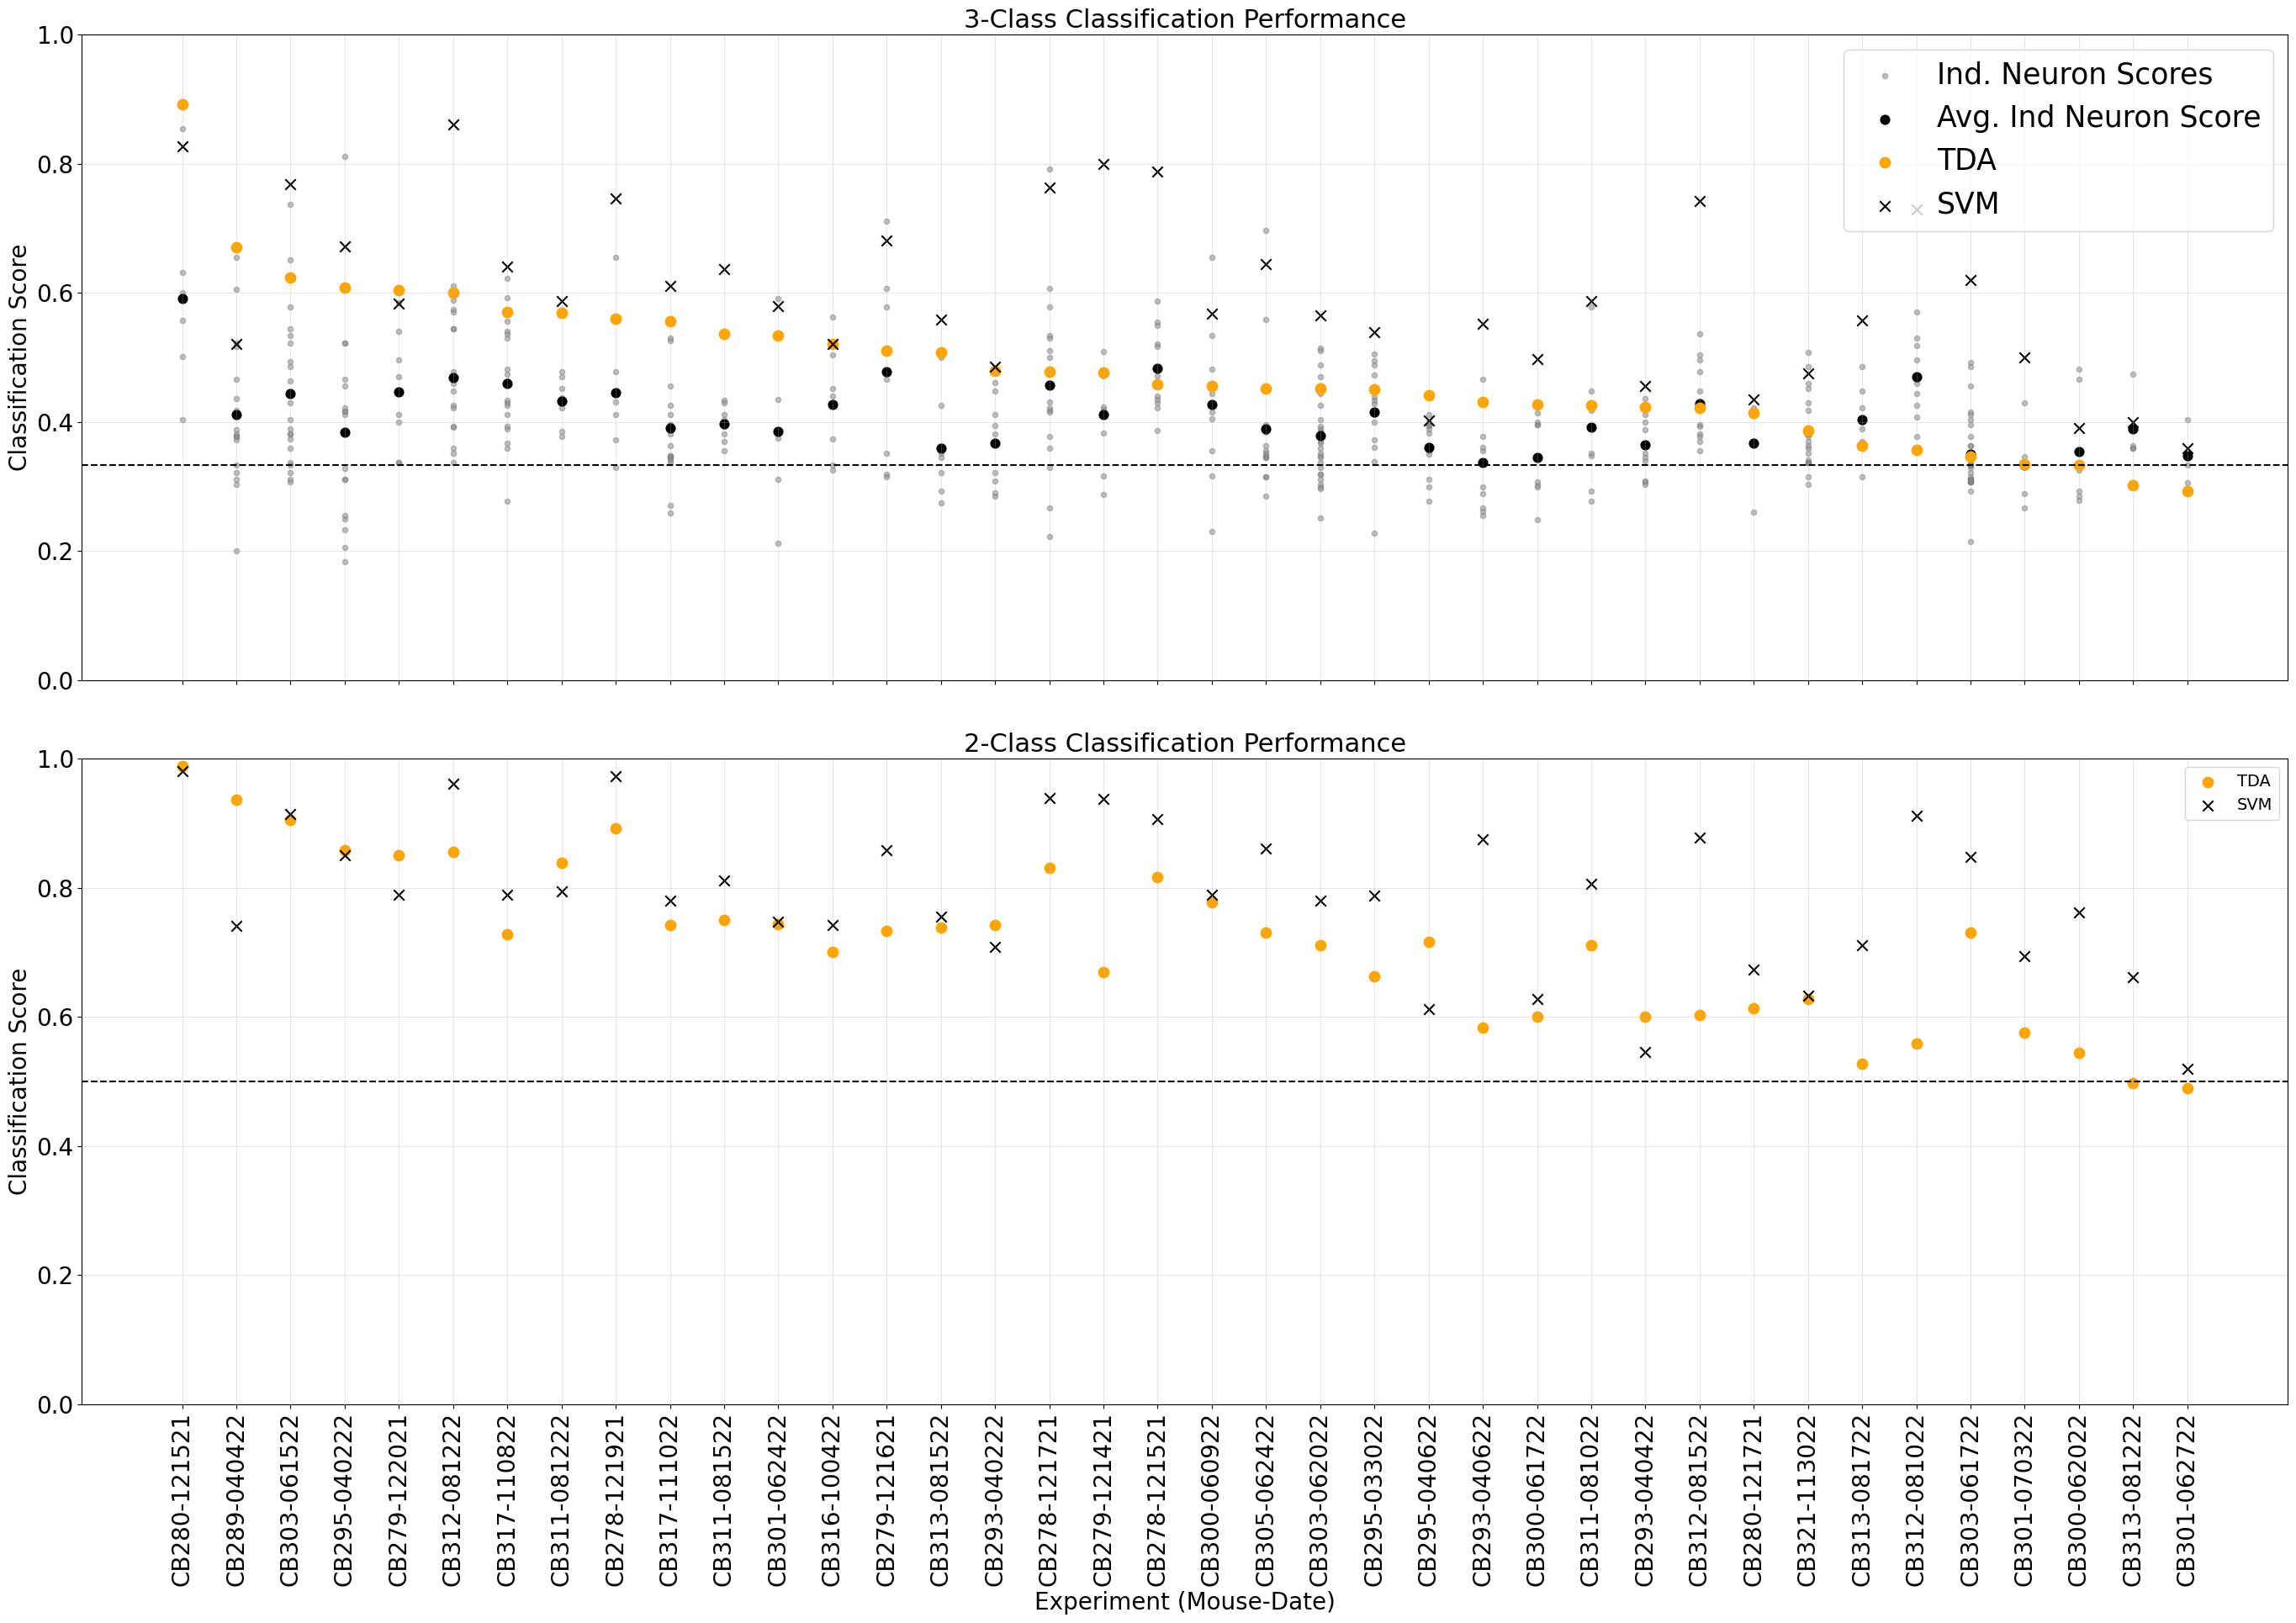

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Sort the dataframe by 'TDA 3-class' descending before plotting
merged_df = merged_df.sort_values(by='TDA 3-class', ascending=False).reset_index(drop=True)

# 2. Set up the figure with two subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(28, 20), sharex=True)
plt.subplots_adjust(hspace=0.1) # Reduce space between plots

# X-axis data for alignment (now sorted)
experiments = merged_df['Experiment']
x_ticks = np.arange(len(experiments))

# --- Plot 1: 3-class data ---
ax1.set_title('3-Class Classification Performance')
ax1.set_ylabel('Classification Score')
ax1.set_ylim(0, 1)
ax1.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_3class = 1/3
ax1.axhline(y=chance_3class, color='black', linestyle='--')

# Plot Individual Neuron Scores (gray dots) and Average (black dot) for 3-class
for i, exp in enumerate(experiments):
    mouse = merged_df.iloc[i]['Mouse']
    date = merged_df.iloc[i]['Date']
    key = (mouse, date)
    
    if key in MD_to_ind_neuron_scores:
        scores = MD_to_ind_neuron_scores[key]
        x_values = [i] * len(scores) # All scores for this exp align vertically
        
        # Plot individual gray dots (only once per legend entry)
        if i == 0:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20, label='Ind. Neuron Scores')
        else:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20)

# Plot Average Ind Neuron Score (black dot, slightly larger)
ax1.scatter(x_ticks, merged_df['Avg Ind Score'], color='black', s=60, label='Avg. Ind Neuron Score')

# Plot TDA 3-class (orange dot)
ax1.scatter(x_ticks, merged_df['TDA 3-class'], color='orange', marker='o', s=80, label='TDA')

# Plot SVM 3-class (black 'x')
ax1.scatter(x_ticks, merged_df['SVM 3-class'], color='black', marker='x', s=80, label='SVM')

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='small')


# --- Plot 2: 2-class data ---
ax2.set_title('2-Class Classification Performance')
ax2.set_ylabel('Classification Score')
ax2.set_xlabel('Experiment (Mouse-Date)')
ax2.set_ylim(0, 1)
ax2.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_2class = 1/2
ax2.axhline(y=chance_2class, color='black', linestyle='--')

# Plot TDA 2-class (orange dot)
ax2.scatter(x_ticks, merged_df['TDA 2-class'], color='orange', marker='o', s=80, label='TDA')

# Plot SVM 2-class (black 'x')
ax2.scatter(x_ticks, merged_df['SVM 2-class'], color='black', marker='x', s=80, label='SVM')

# Formatting x-axis labels (shared across both subplots)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(experiments, rotation=90) # Rotate for readability
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()

# Save the figure as a PDF before displaying
plt.savefig('classification_performance_TDA_SVM.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Permute Neuron IDs

In [38]:
def permute_neuron_ids(raster):
    """Randomly shuffles the rows (neurons) of a single trial raster."""
    idx = np.random.permutation(raster.shape[0])
    return raster[idx, :]

def get_svm_features(raster, sigma=30):
    """Standard smoothed firing rate features (Flattened)."""
    smoothed = gaussian_filter(raster.astype(float), sigma=(0, sigma))
    return smoothed.flatten()


def evaluate_tda_svm(Mouse, Date, n_repeats=20, test_size=0.3, random_state=42, C=1.0, sigma=30):
    """
    Compare TDA (1-NN on bottleneck distance matrix) vs SVM
    on normal vs neuron-ID-permuted rasters for Taste 0 vs 1.

    Returns
    -------
    pd.DataFrame
        One-row dataframe with summary metrics.
    """
    t0 = MDT_to_trials.get((Mouse, Date, 0), [])
    t1 = MDT_to_trials.get((Mouse, Date, 1), [])
    X_rasters = t0 + t1
    y = np.array([0] * len(t0) + [1] * len(t1))

    # Basic validity checks
    n0, n1 = len(t0), len(t1)
    if n0 < 2 or n1 < 2:
        return pd.DataFrame([{
            "Mouse": Mouse,
            "Date": Date,
            "n_taste0": n0,
            "n_taste1": n1,
            "TDA_normal_mean": np.nan,
            "TDA_normal_std": np.nan,
            "TDA_shuffled_mean": np.nan,
            "TDA_shuffled_std": np.nan,
            "SVM_normal_mean": np.nan,
            "SVM_normal_std": np.nan,
            "SVM_shuffled_mean": np.nan,
            "SVM_shuffled_std": np.nan,
            "Error": "Not enough trials per class (need >=2)."
        }])

    rng = np.random.default_rng(random_state)

    # Features for SVM
    X_svm_norm = np.array([get_svm_features(r, sigma=sigma) for r in X_rasters])

    # Permute neuron IDs per trial (reproducible)
    X_permuted = [r[rng.permutation(r.shape[0]), :] for r in X_rasters]
    X_svm_shuff = np.array([get_svm_features(r, sigma=sigma) for r in X_permuted])

    # Barcodes
    X_barcodes_normal = rasters_to_barcode(X_rasters, dim=0)
    X_barcodes_shuffled = rasters_to_barcode(X_permuted, dim=0)

    # Build bottleneck distance matrices
    n = len(X_barcodes_normal)
    BDM_normal = np.zeros((n, n), dtype=float)
    BDM_shuffled = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            d_norm = bottleneck_zero(X_barcodes_normal[i], X_barcodes_normal[j])
            d_shuf = bottleneck_zero(X_barcodes_shuffled[i], X_barcodes_shuffled[j])

            BDM_normal[i, j] = BDM_normal[j, i] = d_norm
            BDM_shuffled[i, j] = BDM_shuffled[j, i] = d_shuf

    # Splitter / models
    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats, test_size=test_size, random_state=random_state
    )

    svm_model = make_pipeline(
        StandardScaler(with_mean=True),
        SVC(kernel="linear", C=C),
    )
    tda_knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")

    tda_scores_normal, tda_scores_shuffled = [], []
    svm_scores_normal, svm_scores_shuffled = [], []

    try:
        for train_idx, test_idx in splitter.split(np.zeros_like(y), y):
            # ----- TDA -----
            D_train_norm = BDM_normal[np.ix_(train_idx, train_idx)]
            D_test_norm = BDM_normal[np.ix_(test_idx, train_idx)]
            preds_tda_norm = tda_knn.fit(D_train_norm, y[train_idx]).predict(D_test_norm)
            tda_scores_normal.append(accuracy_score(y[test_idx], preds_tda_norm))

            D_train_shuf = BDM_shuffled[np.ix_(train_idx, train_idx)]
            D_test_shuf = BDM_shuffled[np.ix_(test_idx, train_idx)]
            preds_tda_shuf = tda_knn.fit(D_train_shuf, y[train_idx]).predict(D_test_shuf)
            tda_scores_shuffled.append(accuracy_score(y[test_idx], preds_tda_shuf))

            # ----- SVM -----
            preds_svm_norm = svm_model.fit(
                X_svm_norm[train_idx], y[train_idx]
            ).predict(X_svm_norm[test_idx])
            svm_scores_normal.append(accuracy_score(y[test_idx], preds_svm_norm))

            preds_svm_shuf = svm_model.fit(
                X_svm_shuff[train_idx], y[train_idx]
            ).predict(X_svm_shuff[test_idx])
            svm_scores_shuffled.append(accuracy_score(y[test_idx], preds_svm_shuf))

    except ValueError as e:
        return pd.DataFrame([{
            "Mouse": Mouse,
            "Date": Date,
            "n_taste0": n0,
            "n_taste1": n1,
            "TDA_normal_mean": np.nan,
            "TDA_normal_std": np.nan,
            "TDA_shuffled_mean": np.nan,
            "TDA_shuffled_std": np.nan,
            "SVM_normal_mean": np.nan,
            "SVM_normal_std": np.nan,
            "SVM_shuffled_mean": np.nan,
            "SVM_shuffled_std": np.nan,
            "Error": str(e)
        }])

    out = pd.DataFrame([{
        "Mouse": Mouse,
        "Date": Date,
        "n_taste0": n0,
        "n_taste1": n1,
        "TDA_normal_mean": float(np.mean(tda_scores_normal)),
        "TDA_normal_std": float(np.std(tda_scores_normal, ddof=1)) if len(tda_scores_normal) > 1 else 0.0,
        "TDA_shuffled_mean": float(np.mean(tda_scores_shuffled)),
        "TDA_shuffled_std": float(np.std(tda_scores_shuffled, ddof=1)) if len(tda_scores_shuffled) > 1 else 0.0,
        "SVM_normal_mean": float(np.mean(svm_scores_normal)),
        "SVM_normal_std": float(np.std(svm_scores_normal, ddof=1)) if len(svm_scores_normal) > 1 else 0.0,
        "SVM_shuffled_mean": float(np.mean(svm_scores_shuffled)),
        "SVM_shuffled_std": float(np.std(svm_scores_shuffled, ddof=1)) if len(svm_scores_shuffled) > 1 else 0.0,
        "Error": ""
    }])

    return out





# def evaluate_tda_svm(Mouse, Date, n_repeats=20, test_size=0.3,random_state = 42, C = 1.0, sigma = 30):
#     t0 = MDT_to_trials.get((Mouse, Date, 0), [])
#     t1 = MDT_to_trials.get((Mouse, Date, 1), [])
  
#     X_rasters = t0 + t1

#     y = np.array([0]*len(t0) + [1]*len(t1))

#     # --- CREATE THE DATASETS ---
#     # 1. Normal (Unshuffled)
#     X_svm_norm = np.array([get_svm_features(r) for r in X_rasters])
  
#     # 2. Permuted (Shuffled Neuron IDs per trial)
#     X_permuted = [permute_neuron_ids(r) for r in X_rasters]
#     X_svm_shuff = np.array([get_svm_features(r) for r in X_permuted])

#     # ================================================ 
#     #              Build BDM from Normal and Shuffled rasters
#     # ================================================ 
#     X_barcodes_normal = rasters_to_barcode(X_rasters,dim =0)
#     X_barcodes_shuffled = rasters_to_barcode(X_permuted, dim = 0)

#     n = len(X_barcodes_normal)
#     BDM_normal = np.zeros((n, n), dtype=float)
#     BDM_shuffled = np.zeros((n, n), dtype=float)
#     for i in range(n):
#         for j in range(i + 1, n):
#             d = bottleneck_zero(X_barcodes_normal[i], X_barcodes_normal[j])
#             d_sf = bottleneck_zero(X_barcodes_shuffled[i],X_barcodes_shuffled[j])
        
#             BDM_normal[i, j] = d
#             BDM_normal[j, i] = d

#             BDM_shuffled[i, j] = d_sf
#             BDM_shuffled[j, i] = d_sf

#     splitter = StratifiedShuffleSplit(
#         n_splits=n_repeats, test_size=test_size, random_state=random_state
#     )

#     svm_model = make_pipeline(
#         StandardScaler(with_mean=True),
#         SVC(kernel="linear", C=C),
#     )

#     tda_knn = KNeighborsClassifier(n_neighbors=1, metric="precomputed")


#     tda_scores_normal = []
#     tda_scores_shuffled = []

#     svm_scores_normal = []
#     svm_scores_shuffled = []
#     for train_idx, test_idx in splitter.split(np.zeros_like(y), y):

#         # ====== TDA Block=================
#         D_train_normal = BDM_normal[np.ix_(train_idx, train_idx)]
#         D_test_normal = BDM_normal[np.ix_(test_idx, train_idx)]

#         D_train_shuffled = BDM_shuffled[np.ix_(train_idx, train_idx)]
#         D_test_shuffled = BDM_shuffled[np.ix_(test_idx, train_idx)]

#         # normal data tda knn run
#         preds_normal= tda_knn.fit(D_train_normal, y[train_idx]).predict(D_test_normal)
#         tda_scores_normal.append(accuracy_score(y[test_idx], preds_normal))

#         # shuffled data tda knn run
#         preds_shuffled= tda_knn.fit(D_train_shuffled, y[train_idx]).predict(D_test_shuffled)
#         tda_scores_shuffled.append(accuracy_score(y[test_idx], preds_shuffled))

#         # ====== SVM Block=================
#         preds_normal_svm = svm_model.fit(X_svm_norm[train_idx],y[train_idx]).predict(X_svm_norm[test_idx])
#         svm_scores_normal.append(accuracy_score(y[test_idx],preds_normal_svm))

#         preds_shuffled_svm = svm_model.fit(X_svm_shuff[train_idx],y[train_idx]).predict(X_svm_shuff[test_idx])
#         svm_scores_shuffled.append(accuracy_score(y[test_idx],preds_shuffled_svm))


#     # take the mean scores out of all splits.
#     mean_tda_score_normal = np.mean(tda_scores_normal)
#     mean_tda_score_shuffled = np.mean(tda_scores_shuffled)
#     mean_svm_scores_normal = np.mean(svm_scores_normal)
#     mean_svm_score_shuffled = np.mean(svm_scores_shuffled)

  
#     # report results as a data frame
    




    



In [39]:
from tqdm import tqdm
rows = []

for row in tqdm(pairs.itertuples(index=False), total=len(pairs), desc="Permutation invariance"):
    Mouse = row.Mouse
    Date = str(row.Date).zfill(6)

    try:
        out = evaluate_tda_svm(Mouse=Mouse, Date=Date)  # expected: one-row DataFrame
        rows.append(out)
    except Exception as e:
        rows.append(pd.DataFrame([{
            "Mouse": Mouse,
            "Date": Date,
            "n_taste0": np.nan,
            "n_taste1": np.nan,
            "TDA_normal_mean": np.nan,
            "TDA_normal_std": np.nan,
            "TDA_shuffled_mean": np.nan,
            "TDA_shuffled_std": np.nan,
            "SVM_normal_mean": np.nan,
            "SVM_normal_std": np.nan,
            "SVM_shuffled_mean": np.nan,
            "SVM_shuffled_std": np.nan,
            "Error": str(e),
        }]))

results_permutation_invariance = (
    pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
)


results_permutation_invariance.to_csv("permutation_invariance_scores.csv", index=False)

results_permutation_invariance.head()


Permutation invariance: 100%|██████████| 38/38 [01:36<00:00,  2.55s/it]


,Mouse,Date,n_taste0,n_taste1,TDA_normal_mean,TDA_normal_std,TDA_shuffled_mean,TDA_shuffled_std,SVM_normal_mean,SVM_normal_std,SVM_shuffled_mean,SVM_shuffled_std,Error
0,CB279,121621,30,30,0.733333,0.073438,0.733333,0.073438,0.858333,0.052473,0.727778,0.082402,
1,CB279,121421,23,29,0.668750,0.086270,0.668750,0.086270,0.937500,0.078535,0.628125,0.106289,
2,CB279,122021,30,29,0.850000,0.051299,0.850000,0.051299,0.788889,0.089399,0.711111,0.101323,
3,CB278,121521,29,20,0.816667,0.074536,0.816667,0.074536,0.906667,0.095268,0.576667,0.112961,
4,CB278,121721,29,30,0.830556,0.049280,0.830556,0.049280,0.938889,0.056713,0.483333,0.106787,


In [40]:
merged_df

,Mouse,Date,TDA 3-class,TDA 2-class,SVM 3-class,SVM 2-class,Experiment,Avg Ind Score
0,CB280,121521,0.892308,0.988889,0.826923,0.980556,CB280-121521,0.591503
1,CB289,040422,0.670588,0.936364,0.520588,0.740909,CB289-040422,0.411052
2,CB303,061522,0.624074,0.905556,0.768519,0.913889,CB303-061522,0.444673
3,CB295,040222,0.608333,0.858333,0.672222,0.850000,CB295-040222,0.383660
4,CB279,122021,0.603704,0.850000,0.583333,0.788889,CB279-122021,0.447222
5,CB312,081222,0.600000,0.855556,0.861111,0.961111,CB312-081222,0.468696
6,CB317,110822,0.570370,0.727778,0.640741,0.788889,CB317-110822,0.460082
7,CB311,081222,0.568519,0.838889,0.587037,0.794444,CB311-081222,0.431746
8,CB278,121921,0.559615,0.891667,0.746154,0.972222,CB278-121921,0.445938
9,CB317,111022,0.555556,0.741667,0.611111,0.780556,CB317-111022,0.390838


In [41]:
# ...existing code...
# --- normalize keys ---
results_permutation_invariance = pd.read_csv('permutation_invariance_scores.csv')
merged_df_check = merged_df.copy()
rpi_check = results_permutation_invariance.copy()

merged_df_check["Date"] = merged_df_check["Date"].astype(str).str.zfill(6)
rpi_check["Date"] = rpi_check["Date"].astype(str).str.zfill(6)

# --- safety: unique Mouse-Date in permutation results ---
dup_mask = rpi_check.duplicated(subset=["Mouse", "Date"], keep=False)
if dup_mask.any():
    raise ValueError(
        "results_permutation_invariance has duplicate Mouse-Date keys:\n"
        + str(rpi_check.loc[dup_mask, ["Mouse", "Date"]].drop_duplicates())
    )

# --- check all merged_df keys exist in permutation table ---
key_cols = ["Mouse", "Date"]
missing_keys = (
    merged_df_check[key_cols]
    .merge(rpi_check[key_cols], on=key_cols, how="left", indicator=True)
    .query('_merge == "left_only"')
)
if len(missing_keys) > 0:
    raise ValueError(
        "Missing Mouse-Date keys in results_permutation_invariance:\n"
        + str(missing_keys[key_cols].drop_duplicates())
    )

# --- verify normal-score consistency before combining ---
check_df = merged_df_check.merge(
    rpi_check[["Mouse", "Date", "TDA_normal_mean", "SVM_normal_mean"]],
    on=["Mouse", "Date"],
    how="left",
)

check_df["TDA_match"] = np.isclose(
    check_df["TDA_normal_mean"], check_df["TDA 2-class"],
    atol=1e-10, rtol=1e-8, equal_nan=True
)
check_df["SVM_match"] = np.isclose(
    check_df["SVM_normal_mean"], check_df["SVM 2-class"],
    atol=1e-10, rtol=1e-8, equal_nan=True
)

mismatch_df = check_df.loc[
    ~(check_df["TDA_match"] & check_df["SVM_match"]),
    ["Mouse", "Date", "TDA 2-class", "TDA_normal_mean", "SVM 2-class", "SVM_normal_mean"]
]

if len(mismatch_df) > 0:
    print(f"Found {len(mismatch_df)} Mouse-Date mismatches:")
    display(mismatch_df)
    raise ValueError("Normal scores do not match between merged_df and results_permutation_invariance.")
else:
    print("Check passed: TDA_normal_mean == TDA 2-class and SVM_normal_mean == SVM 2-class.")

# --- build final_results in merged_df order ---
final_results = merged_df_check.copy()

shuf_lookup = (
    rpi_check.set_index(["Mouse", "Date"])[["TDA_shuffled_mean", "SVM_shuffled_mean"]]
)

idx = pd.MultiIndex.from_frame(final_results[["Mouse", "Date"]])
final_results["TDA 2-class Shuffled"] = shuf_lookup.reindex(idx)["TDA_shuffled_mean"].to_numpy()
final_results["SVM 2-class shuffled"] = shuf_lookup.reindex(idx)["SVM_shuffled_mean"].to_numpy()

final_results.head()

Check passed: TDA_normal_mean == TDA 2-class and SVM_normal_mean == SVM 2-class.


,Mouse,Date,TDA 3-class,TDA 2-class,SVM 3-class,SVM 2-class,Experiment,Avg Ind Score,TDA 2-class Shuffled,SVM 2-class shuffled
0,CB280,121521,0.892308,0.988889,0.826923,0.980556,CB280-121521,0.591503,0.988889,0.963889
1,CB289,040422,0.670588,0.936364,0.520588,0.740909,CB289-040422,0.411052,0.936364,0.381818
2,CB303,061522,0.624074,0.905556,0.768519,0.913889,CB303-061522,0.444673,0.905556,0.419444
3,CB295,040222,0.608333,0.858333,0.672222,0.850000,CB295-040222,0.383660,0.858333,0.537500
4,CB279,122021,0.603704,0.850000,0.583333,0.788889,CB279-122021,0.447222,0.850000,0.711111


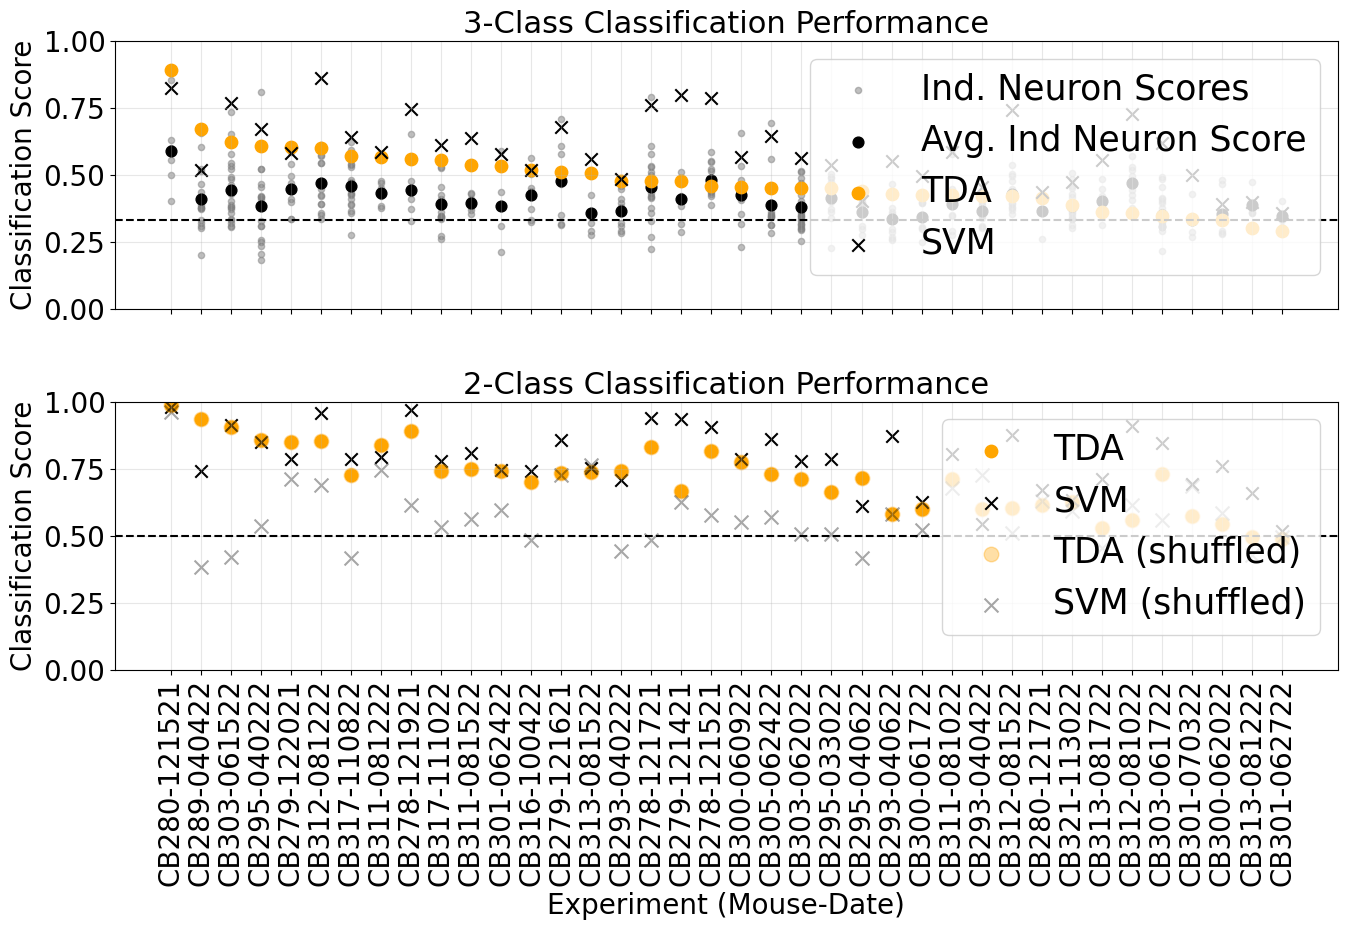

In [42]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

# Use final_results (contains shuffled columns) and keep original sort behavior
plot_df = final_results.copy()
plot_df = plot_df.sort_values(by='TDA 3-class', ascending=False).reset_index(drop=True)

# 2. Set up the figure with two subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
plt.subplots_adjust(hspace=0.1)  # Reduce space between plots

# X-axis data for alignment (now sorted)
experiments = plot_df['Experiment']
x_ticks = np.arange(len(experiments))

# --- Plot 1: 3-class data --- (kept as-is)
ax1.set_title('3-Class Classification Performance')
ax1.set_ylabel('Classification Score')
ax1.set_ylim(0, 1)
ax1.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_3class = 1/3
ax1.axhline(y=chance_3class, color='black', linestyle='--')

# Plot Individual Neuron Scores (gray dots) and Average (black dot) for 3-class
for i, exp in enumerate(experiments):
    mouse = plot_df.iloc[i]['Mouse']
    date = plot_df.iloc[i]['Date']
    key = (mouse, date)

    if key in MD_to_ind_neuron_scores:
        scores = MD_to_ind_neuron_scores[key]
        x_values = [i] * len(scores)  # All scores for this exp align vertically

        # Plot individual gray dots (only once per legend entry)
        if i == 0:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20, label='Ind. Neuron Scores')
        else:
            ax1.scatter(x_values, scores, color='gray', alpha=0.5, s=20)

# Plot Average Ind Neuron Score (black dot, slightly larger)
ax1.scatter(x_ticks, plot_df['Avg Ind Score'], color='black', s=60, label='Avg. Ind Neuron Score')

# Plot TDA 3-class (orange dot)
ax1.scatter(x_ticks, plot_df['TDA 3-class'], color='orange', marker='o', s=80, label='TDA')

# Plot SVM 3-class (black 'x')
ax1.scatter(x_ticks, plot_df['SVM 3-class'], color='black', marker='x', s=80, label='SVM')

ax1.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='small')

# --- Plot 2: 2-class data + shuffled ---
ax2.set_title('2-Class Classification Performance')
ax2.set_ylabel('Classification Score')
ax2.set_xlabel('Experiment (Mouse-Date)')
ax2.set_ylim(0, 1)
ax2.grid(axis='both', linestyle='-', alpha=0.3)

# Define reference lines
chance_2class = 1/2
ax2.axhline(y=chance_2class, color='black', linestyle='--')

# Original 2-class
ax2.scatter(x_ticks, plot_df['TDA 2-class'], color='orange', marker='o', s=80, label='TDA')
ax2.scatter(x_ticks, plot_df['SVM 2-class'], color='black', marker='x', s=80, label='SVM')

# Shuffled 2-class (same style family, faded and slightly larger)
ax2.scatter(
    x_ticks, plot_df['TDA 2-class Shuffled'],
    color='orange', marker='o', s=110, alpha=0.35, label='TDA (shuffled)'
)
ax2.scatter(
    x_ticks, plot_df['SVM 2-class shuffled'],
    color='black', marker='x', s=100, alpha=0.35, label='SVM (shuffled)'
)

# Formatting x-axis labels (shared across both subplots)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(experiments, rotation=90)  # Rotate for readability
ax2.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize='small')

plt.tight_layout()

# Save the figure as a PDF before displaying
plt.savefig('classification_performance_TDA_SVM_with_shuffled.pdf', format='pdf', bbox_inches='tight')

# 3-panels

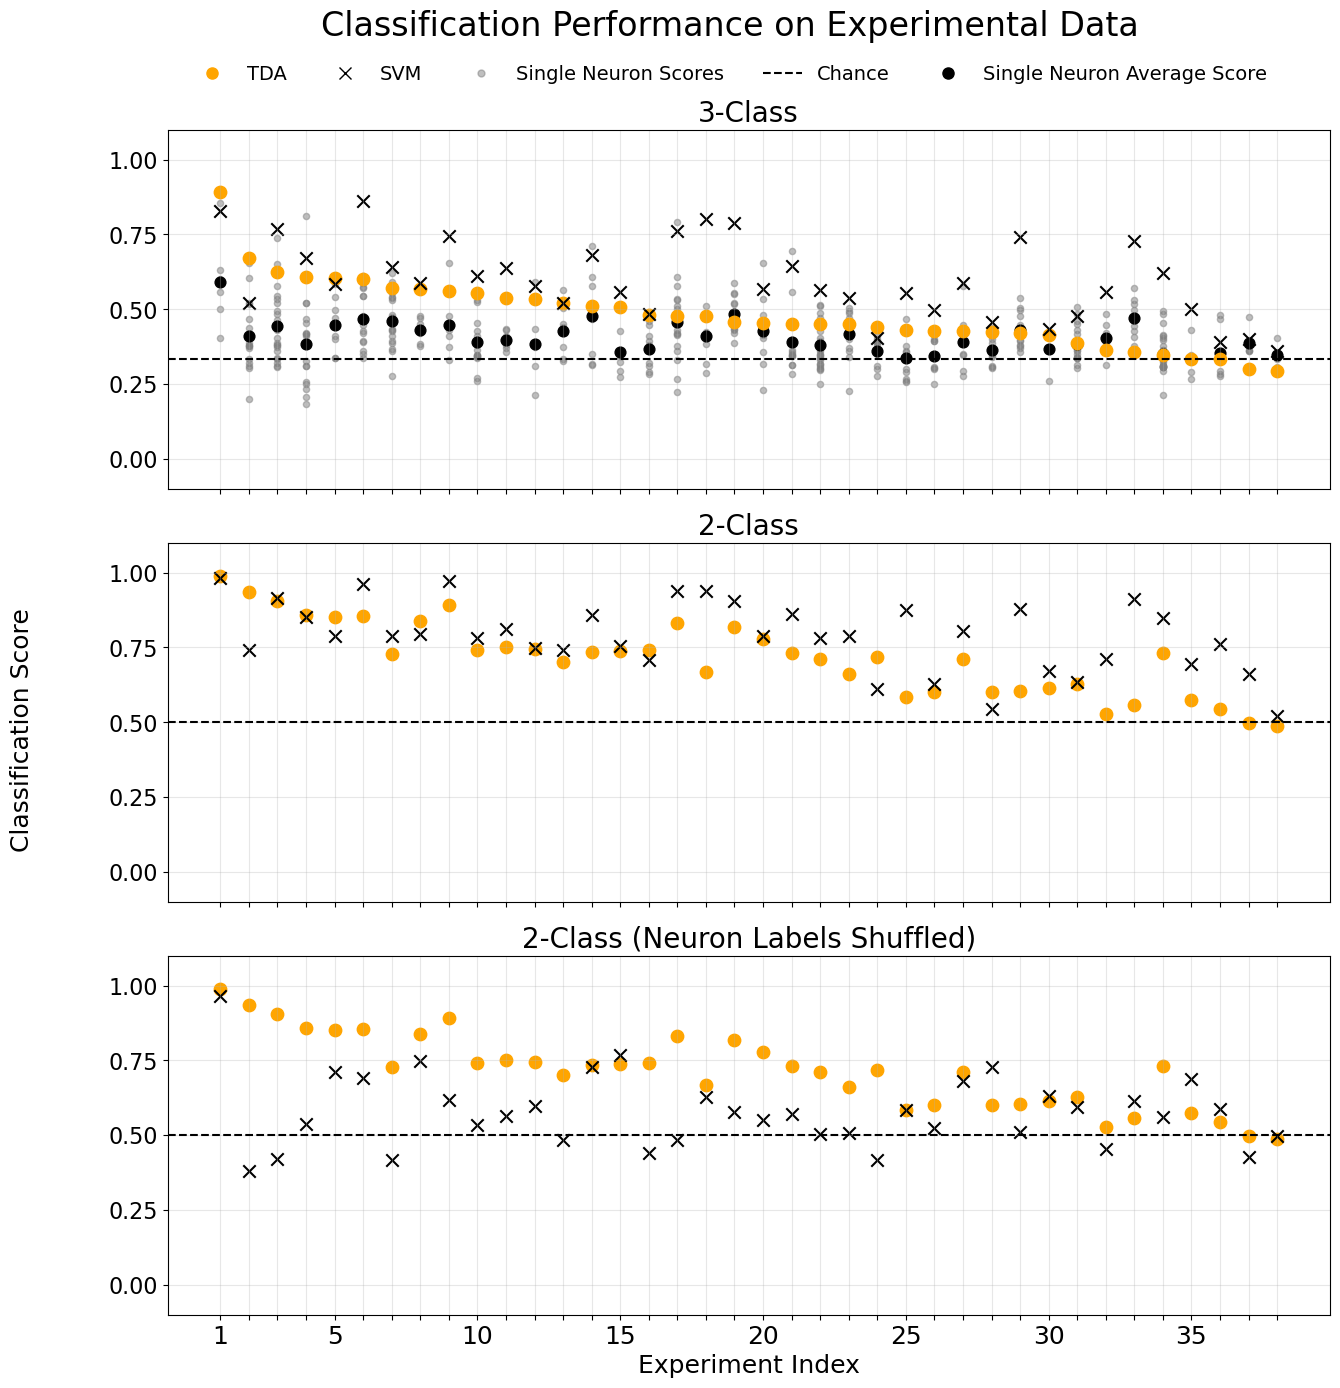

In [95]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# ---- font controls ----
legend_font_size = 14
font_size = 30
axes_titlesize = 20
axes_labelsize = 18
xtick_labelsize = 18
ytick_labelsize = 16
figure_titlesize = 24

# y_ticks = [0.25,0.5,0.75,1.0]

plt.rcParams.update({
    "font.size": font_size,
    "axes.titlesize": axes_titlesize,
    "axes.labelsize": axes_labelsize,
    "xtick.labelsize": xtick_labelsize,
    "ytick.labelsize": ytick_labelsize,
    "legend.fontsize": legend_font_size,
    "figure.titlesize": figure_titlesize,
})

# Use final_results (contains shuffled columns) and keep original sort behavior
plot_df = final_results.copy()
plot_df = plot_df.sort_values(by="TDA 3-class", ascending=False).reset_index(drop=True)

# 3 stacked panels with shared y-axis
fig, axs = plt.subplots(3, 1, figsize=(15, 15), sharex=True, sharey=True, constrained_layout=False)

fig.suptitle("Classification Performance on Experimental Data", fontsize=figure_titlesize)
fig.subplots_adjust(top=0.9, hspace=0.15)  # leave room for title + legend

# shared y-axis label
fig.supylabel("Classification Score", fontsize=axes_labelsize)
# axs[0].set_ylim(0.5, 5)
# axs[0].set_yticks()

# X-axis data
experiments = plot_df["Experiment"]
x_ticks = np.arange(len(experiments))

# show x labels every 5, but keep all x-ticks
tick_positions = np.arange(len(experiments))
tick_labels = [str(i + 1) if (i == 0 or (i + 1) % 5 == 0) else "" for i in range(len(experiments))]

# common y formatting
for ax in axs:
    ax.set_ylim(0, 1)
    ax.grid(axis="both", linestyle="-", alpha=0.3)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# --- Panel 1: 3-class data (exactly as-is) ---
ax1 = axs[0]
ax1.set_title("3-Class")
chance_3class = 1 / 3
ax1.axhline(y=chance_3class, color="black", linestyle="--", label="Chance")
ax1.set_ylim(-0.1,1.1)

for i, exp in enumerate(experiments):
    mouse = plot_df.iloc[i]["Mouse"]
    date = plot_df.iloc[i]["Date"]
    key = (mouse, date)

    if key in MD_to_ind_neuron_scores:
        scores = MD_to_ind_neuron_scores[key]
        x_values = [i] * len(scores)

        if i == 0:
            ax1.scatter(x_values, scores, color="gray", alpha=0.5, s=20, label="Ind. Neuron Scores")
        else:
            ax1.scatter(x_values, scores, color="gray", alpha=0.5, s=20)

ax1.scatter(x_ticks, plot_df["Avg Ind Score"], color="black", s=60, label="Avg. Ind Neuron Score")
ax1.scatter(x_ticks, plot_df["TDA 3-class"], color="orange", marker="o", s=80, label="TDA")
ax1.scatter(x_ticks, plot_df["SVM 3-class"], color="black", marker="x", s=80, label="SVM")
# ax1.legend(loc="upper right", fontsize=legend_font_size)
# ax1.set_yticks(y_ticks)


# --- Panel 2: binary classification, original only ---
ax2 = axs[1]
ax2.set_title("2-Class")
chance_2class = 1 / 2
ax2.axhline(y=chance_2class, color="black", linestyle="--", label="Chance")
ax2.scatter(x_ticks, plot_df["TDA 2-class"], color="orange", marker="o", s=80, label="TDA")
ax2.scatter(x_ticks, plot_df["SVM 2-class"], color="black", marker="x", s=80, label="SVM")
# ax2.legend(loc="upper right", fontsize=legend_font_size)
# ax2.set_yticks(y_ticks)

# --- Panel 3: binary classification, shuffled only ---
ax3 = axs[2]
ax3.set_title("2-Class (Neuron Labels Shuffled)")
ax3.set_xlabel("Experiment Index")
ax3.axhline(y=chance_2class, color="black", linestyle="--", label="Chance")
ax3.scatter(x_ticks, plot_df["TDA 2-class Shuffled"], color="orange", marker="o", s=80, label="TDA (shuffled)")
ax3.scatter(x_ticks, plot_df["SVM 2-class shuffled"], color="black", marker="x", s=80, label="SVM (shuffled)")
# ax3.legend(loc="upper right", fontsize=legend_font_size)

# Keep all x-ticks, but show only every 5th x-label
ax3.set_xticks(tick_positions)
ax3.set_xticklabels(tick_labels, rotation=0)
# ax3.set_yticks(y_ticks)

# shared legend for all panels
legend_handles = [
    Line2D([0], [0], marker="o", color="orange", linestyle="None", markersize=8, label="TDA"),
    Line2D([0], [0], marker="x", color="black", linestyle="None", markersize=8, label="SVM"),
    Line2D([0], [0], marker="o", color="gray", linestyle="None", markersize=5, alpha=0.5, label="Single Neuron Scores"),
    Line2D([0], [0], color="black", linestyle="--", label="Chance"),
    Line2D([0], [0], marker="o", color="black", linestyle="None", markersize=8, label="Single Neuron Average Score"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    frameon=False,
    bbox_to_anchor=(0.5, 0.955),
    fontsize=legend_font_size,
)


plt.savefig("classification_performance_TDA_SVM_3panels.pdf", format="pdf", bbox_inches="tight")
plt.show()